In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
from datasets import load_dataset

d:\Study\data science portfolio projects\Emotion Predictor\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_url = "https://huggingface.co/datasets/dair-ai/emotion"

In [4]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

In [5]:
emotion_dataset = load_dataset("dair-ai/emotion")

In [6]:
emotion_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [7]:
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset["train"]["label"]

In [8]:
test_text = emotion_dataset["test"]["text"]
test_label = emotion_dataset["test"]["label"]

In [9]:
len(test_label)

2000

In [10]:
label_name = emotion_dataset["train"].features["label"].names
label_name

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [11]:
for i in train_label:
    print(label_name[i])

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love
sadness
joy
anger
sadness
joy
joy
sadness
sadness
sadness
fear
anger
fear
joy
joy
anger
sadness
sadness
sadness
anger
joy
joy
fear
surprise
anger
joy
joy
joy
joy
anger
joy
joy
joy
joy
joy
sadness
sadness
joy
love
joy
anger
joy
sadness
anger
fear
joy
sadness
sadness
surprise
joy
joy
joy
love
fear
fear
surprise
anger
anger
sadness
love
joy
sadness
sadness
joy
sadness
sadness
sadness
joy
joy
joy
anger
sadness
anger
anger
anger
joy
joy
joy
joy
sadness
fear
love
anger
sadness
anger
love
sadness
joy
joy
sadness
anger
love
joy
joy
joy
sadness
joy
joy
joy
joy
sadness
joy
joy
love
sadness
sadness
joy
joy
sadness
joy
joy
fear
fear
fear
sadness
love
joy
joy
love
fear
surprise
joy
joy
joy
joy
anger
fear
joy
anger
love
anger
sadness
joy
sadness
anger
joy
surprise
sadness
anger
anger
sadness
joy
fear
joy
joy
fear
sadness
surprise
surprise
joy
anger
fear
anger
sadness
anger
sadness
fear
sadness
joy
surprise
fear
joy
anger
joy
anger
joy
f

In [12]:
df_train = pd.DataFrame(
    {"text": train_text, "label": [label_name[i] for i in train_label]}
)

In [13]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [14]:
df_test = pd.DataFrame(
    {"text": test_text, "label": [label_name[i] for i in test_label]}
)

In [15]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [16]:
df_test.isnull().sum(), df_train.isnull().sum()

(text     0
 label    0
 dtype: int64,
 text     0
 label    0
 dtype: int64)

In [17]:
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

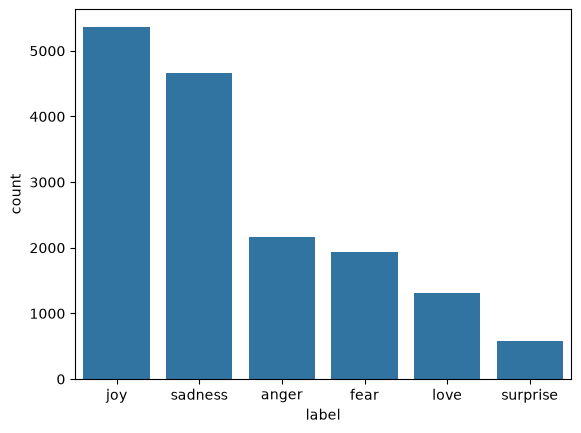

In [18]:
sns.countplot(x="label", data=df_train, order=df_train["label"].value_counts().index)

In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer  # type: ignore
from tensorflow.keras.preprocessing.sequence import pad_sequences  # type: ignore

max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(df_train["text"])

train_sequence = tokenizer.texts_to_sequences(df_train["text"])
test_sequence = tokenizer.texts_to_sequences(df_test["text"])

padded_train_sequence = pad_sequences(
    train_sequence, maxlen=50, padding="post", truncating="post"
)
padded_test_sequence = pad_sequences(
    test_sequence, maxlen=50, padding="post", truncating="post"
)

train_labels = np.array(train_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_labels))

print(f"Vocabulary Size: {len(tokenizer.word_index)}" )
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


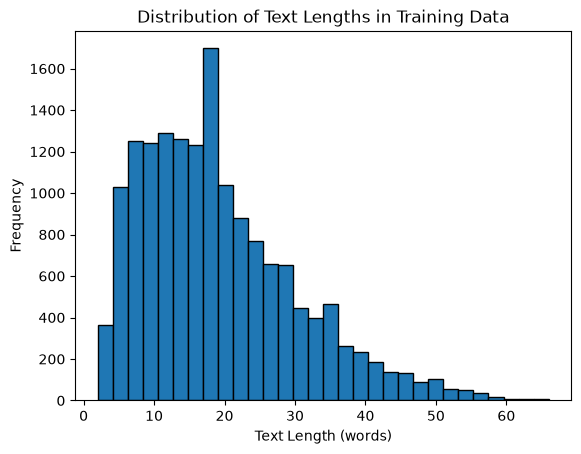

In [20]:
lengths = df_train["text"].apply(lambda x: len(x.split()))
plt.hist(lengths, bins=30, edgecolor='black')
plt.xlabel('Text Length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Text Lengths in Training Data')
plt.show()

In [21]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(train_labels), y=train_label
)

In [22]:
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [23]:
from tensorflow.keras.callbacks import EarlyStopping # type:ignore

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [24]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

2.21.0
[]


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN , Embedding , Dense , Dropout , LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim=max_words , output_dim=128 , input_length= 50),
    SimpleRNN(units = 128 , return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units = 64),
    Dropout(0.5),
    Dense(units=num_classes , activation='softmax')
])

rnn_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

d:\Study\data science portfolio projects\Emotion Predictor\backend\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [26]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.1571 - loss: 1.9161 - val_accuracy: 0.2075 - val_loss: 1.7757
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.1586 - loss: 1.8036 - val_accuracy: 0.1120 - val_loss: 1.8009
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.1629 - loss: 1.7837 - val_accuracy: 0.1080 - val_loss: 1.7953
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.1719 - loss: 1.7760 - val_accuracy: 0.1165 - val_loss: 1.7981


Model 2 - Standard LSTM

In [27]:
lstm_model = Sequential(
    [
        Embedding(input_dim=max_words, output_dim=128, input_length=50),
        LSTM(units=128, return_sequences=True),
        Dropout(0.5),
        LSTM(units=64),
        Dropout(0.5),
        Dense(units=num_classes, activation="softmax"),
    ]
)

lstm_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [28]:
lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.1424 - loss: 1.7937 - val_accuracy: 0.0330 - val_loss: 1.8256
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1337 - loss: 1.7938 - val_accuracy: 0.0330 - val_loss: 1.8016
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1279 - loss: 1.7927 - val_accuracy: 0.1775 - val_loss: 1.7916
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1604 - loss: 1.7776 - val_accuracy: 0.1915 - val_loss: 1.7454
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.2161 - loss: 1.6219 - val_accuracy: 0.1345 - val_loss: 1.7025
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.1445 - loss: 1.7848 - val_accuracy: 0.3330 - val_loss: 1.7666
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1357 - loss: 1.7870 - val_accuracy: 0.0435 - val_loss: 1.7874
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.1112 - loss: 1.7866 - 

In [29]:
gru_model = Sequential(
    [
        Embedding(input_dim=max_words, output_dim=128, input_length=50),
        GRU(units=128, return_sequences=True),
        Dropout(0.5),
        GRU(units=64),
        Dropout(0.5),
        Dense(units=num_classes, activation="softmax"),
    ]
)

gru_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [30]:
gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.1576 - loss: 1.7957 - val_accuracy: 0.3470 - val_loss: 1.7586
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.1507 - loss: 1.7954 - val_accuracy: 0.2905 - val_loss: 1.7670
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.1564 - loss: 1.7943 - val_accuracy: 0.3430 - val_loss: 1.7799
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.1459 - loss: 1.7934 - val_accuracy: 0.2855 - val_loss: 1.7666
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3470 - loss: 1.7586
GRU Loss: 1.7585896253585815
GRU Accuracy: 0.34700000286102295


In [31]:
from tensorflow.keras.layers import Bidirectional # type:ignore
BiGru = Sequential(
    [
        Embedding(input_dim=max_words, output_dim=300, input_length=50),
        Bidirectional(GRU(units=128, return_sequences=True)),
        Dropout(0.5),
        Bidirectional(GRU(units=64)),
        Dropout(0.5),
        Dense(units=num_classes, activation="softmax"),
    ]
)

BiGru.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

BiGru.summary()

d:\Study\data science portfolio projects\Emotion Predictor\backend\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
BiGru.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

Bi_gru_loss, Bi_gru_accuracy = BiGru.evaluate(padded_test_sequence, test_labels)
print(f"Bi_GRU Loss: {Bi_gru_loss}")
print(f"Bi_GRU Accuracy: {Bi_gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 56ms/step - accuracy: 0.5492 - loss: 1.0701 - val_accuracy: 0.8900 - val_loss: 0.3661
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9199 - loss: 0.2304 - val_accuracy: 0.9120 - val_loss: 0.2389
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9444 - loss: 0.1485 - val_accuracy: 0.9225 - val_loss: 0.2159
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9572 - loss: 0.1119 - val_accuracy: 0.9185 - val_loss: 0.2363
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9747 - loss: 0.0743 - val_accuracy: 0.9280 - val_loss: 0.2408
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.9756 - loss: 0.0671 - val_accuracy: 0.9180 - val_loss: 0.3026
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9225 - loss: 0.2159
Bi_GRU Loss: 0.21589328348636627
Bi_GRU Accuracy: 0.9225000143051147


In [ ]:
from sklearn.metrics import confusion_matrix

BiGru_predictions = np.argmax(BiGru.predict(padded_test_sequence), axis=1)

cm = confusion_matrix(test_label, BiGru_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_name, yticklabels=label_name)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - BiGRU Model')
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


TypeError: got an unexpected keyword argument 'annot'